# EDA

In [1]:
# First step to every EDA is reading and analyzing the data we have which is cleaned
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

arrests = pd.read_csv('arrests_cleaned.csv')
crashes = pd.read_csv('crashes_cleaned.csv', low_memory=False)

arrests['ARREST_DATE'] = pd.to_datetime(arrests['ARREST_DATE'])
crashes['CRASH DATE'] = pd.to_datetime(crashes['CRASH DATE'])

print('Arrests:', arrests.shape)
print('Crashes:', crashes.shape)

Arrests: (278953, 23)
Crashes: (2000126, 34)


In [2]:
# Let's look at the features and central tendency also the spread
# We can see how to handle outliers and informs us of feature scaling
print("=== ARRESTS SUMMARY ===")
display(arrests.describe())

print("\n=== CRASHES SUMMARY ===")
display(crashes[['NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED','NUMBER OF PEDESTRIANS INJURED', 'NUMBER OF CYCLIST INJURED','NUMBER OF MOTORIST INJURED']].describe())

=== ARRESTS SUMMARY ===


,ARREST_KEY,ARREST_DATE,PD_CD,KY_CD,ARREST_PRECINCT,JURISDICTION_CODE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,hour,day_of_week,month,year
count,2.789530e+05,278953,278953.000000,278953.000000,278953.000000,278953.000000,2.789530e+05,278953.000000,278953.000000,278953.000000,278953.0,278953.000000,278953.000000,278953.0
mean,3.085697e+08,2025-06-27 06:14:39.244891648,443.764512,258.898119,63.047255,0.932132,1.005315e+06,207515.629314,40.736243,-73.923782,0.0,2.852212,6.383756,2025.0
min,2.987043e+08,2025-01-01 00:00:00,12.000000,0.000000,1.000000,0.000000,-7.400000e+01,40.000000,40.500390,-74.252488,0.0,0.000000,1.000000,2025.0
25%,3.038432e+08,2025-03-29 00:00:00,157.000000,117.000000,40.000000,0.000000,9.906010e+05,184932.000000,40.674210,-73.977117,0.0,1.000000,3.000000,2025.0
50%,3.086091e+08,2025-06-25 00:00:00,439.000000,341.000000,62.000000,0.000000,1.005028e+06,206168.000000,40.732551,-73.924942,0.0,3.000000,6.000000,2025.0
75%,3.135027e+08,2025-09-26 00:00:00,724.000000,344.000000,100.000000,0.000000,1.017273e+06,235780.000000,40.813808,-73.880601,0.0,4.000000,9.000000,2025.0
max,3.182749e+08,2025-12-31 00:00:00,997.000000,995.000000,123.000000,97.000000,1.067185e+06,271597.000000,40.912111,-73.700719,0.0,6.000000,12.000000,2025.0
std,5.664370e+06,NaN,274.632619,148.445543,34.798913,6.820188,2.235094e+04,29840.507845,0.081812,0.076414,0.0,1.884119,3.421162,0.0



=== CRASHES SUMMARY ===


,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF CYCLIST INJURED,NUMBER OF MOTORIST INJURED
count,2.000126e+06,2000126.0,2.000126e+06,2.000126e+06,2.000126e+06
mean,3.201783e-01,0.0,6.059168e-02,3.018510e-02,2.218145e-01
std,6.330236e-01,0.0,2.385799e-01,1.710964e-01,5.878615e-01
min,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00
75%,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00
max,3.000000e+00,0.0,1.000000e+00,1.000000e+00,3.000000e+00


In [3]:
#We handle and deal with the missing data
print("=== ARRESTS Missing Values (%) ===")
arr_missing = (arrests.isnull().sum() / len(arrests) * 100).sort_values(ascending=False)
print(arr_missing[arr_missing > 0].round(2).to_string())

print("\n=== CRASHES Missing Values (%) ===")
cr_missing = (crashes.isnull().sum() / len(crashes) * 100).sort_values(ascending=False)
print(cr_missing[cr_missing > 0].head(15).round(2).to_string())

=== ARRESTS Missing Values (%) ===
Series([], )

=== CRASHES Missing Values (%) ===
VEHICLE TYPE CODE 5              99.55
CONTRIBUTING FACTOR VEHICLE 5    99.54
VEHICLE TYPE CODE 4              98.40
CONTRIBUTING FACTOR VEHICLE 4    98.34
VEHICLE TYPE CODE 3              93.08
CONTRIBUTING FACTOR VEHICLE 3    92.80
OFF STREET NAME                  81.52
CROSS STREET NAME                37.93
ZIP CODE                         24.11
ON STREET NAME                   21.58
VEHICLE TYPE CODE 2              20.83
CONTRIBUTING FACTOR VEHICLE 2    16.51
VEHICLE TYPE CODE 1               0.77


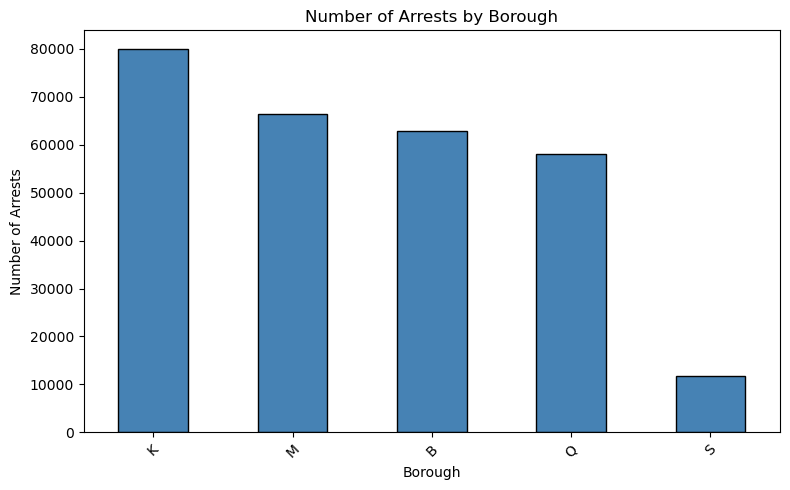

Brooklyn (K) and Manhattan (M) tend to have the highest arrest counts, suggesting hotspot areas for Phase 2 spatial analysis.


In [4]:
# Arrest distribution by the boroughs this one shows geographic concentration
fig, ax = plt.subplots(figsize=(8, 5))
arrests['ARREST_BORO'].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Number of Arrests by Borough')
ax.set_xlabel('Borough')
ax.set_ylabel('Number of Arrests')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.tight_layout()
plt.savefig('eda_arrests_by_borough.png', dpi=150)
plt.show()
print("Brooklyn (K) and Manhattan (M) tend to have the highest arrest counts, suggesting hotspot areas for Phase 2 spatial analysis.")

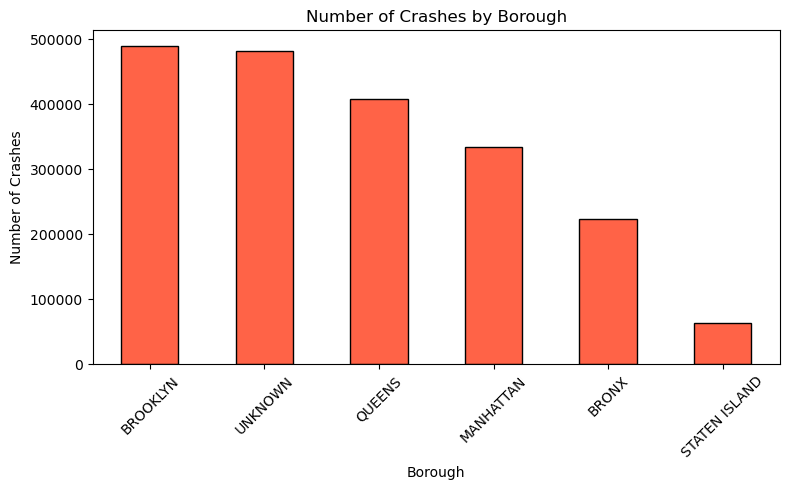

Brooklyn and Queens lead in crash counts. Cross-referencing with arrest data may reveal if high-arrest zones overlap with high-crash zones.


In [5]:
# Which borrows have the most car crashes version
cr_boro = crashes['BOROUGH'].value_counts().dropna()
fig, ax = plt.subplots(figsize=(8, 5))
cr_boro.plot(kind='bar', ax=ax, color='tomato', edgecolor='black')
ax.set_title('Number of Crashes by Borough')
ax.set_xlabel('Borough')
ax.set_ylabel('Number of Crashes')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.tight_layout()
plt.savefig('eda_crashes_by_borough.png', dpi=150)
plt.show()
print("Brooklyn and Queens lead in crash counts. Cross-referencing with arrest data may reveal if high-arrest zones overlap with high-crash zones.")

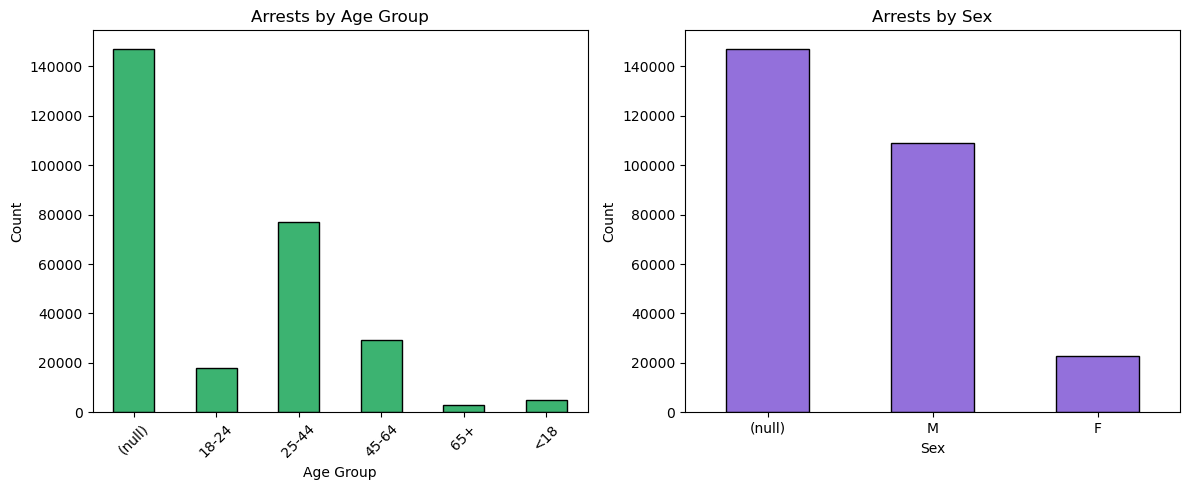

Adults 25-44 make up the majority of arrests. Male arrests far outnumber female arrests. These demographic features will be important inputs for Phase 2 classification models.


In [6]:
# Arrests by demographics
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

arrests['AGE_GROUP'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='mediumseagreen', edgecolor='black')
axes[0].set_title('Arrests by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

arrests['PERP_SEX'].value_counts().plot(kind='bar', ax=axes[1], color='mediumpurple', edgecolor='black')
axes[1].set_title('Arrests by Sex')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('eda_arrests_demographics.png', dpi=150)
plt.show()
print("Adults 25-44 make up the majority of arrests. Male arrests far outnumber female arrests. These demographic features will be important inputs for Phase 2 classification models.")

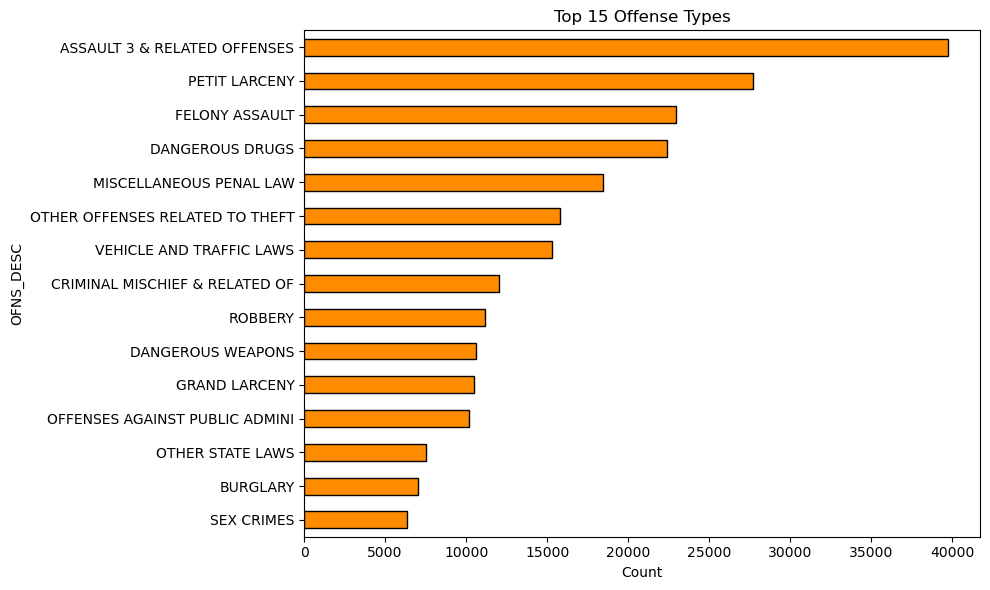

Assault, controlled substance offenses, and petit larceny dominate. These categories will serve as target labels for crime classification in Phase 2.


In [7]:
# What kind of crimes are most common?
top_offenses = arrests['OFNS_DESC'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(10, 6))
top_offenses.plot(kind='barh', ax=ax, color='darkorange', edgecolor='black')
ax.set_title('Top 15 Offense Types')
ax.set_xlabel('Count')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('eda_top_offenses.png', dpi=150)
plt.show()
print("Assault, controlled substance offenses, and petit larceny dominate. These categories will serve as target labels for crime classification in Phase 2.")

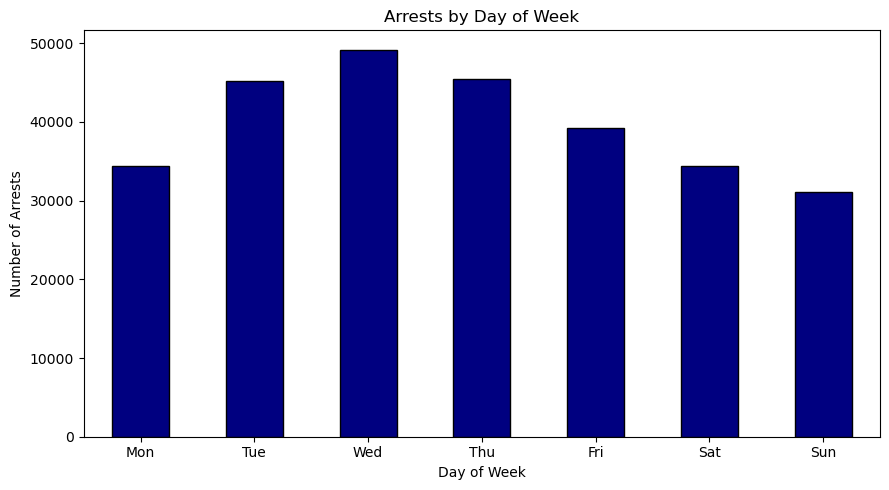

Arrests are fairly distributed across weekdays with slight dips on weekends. Day of week will be used as a temporal feature in Phase 2.


In [8]:
# When are arrests made usually?
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']                                                                                           
fig, ax = plt.subplots(figsize=(9, 5))                                                                                                                   
arrests['day_of_week'].value_counts().sort_index().plot(kind='bar', ax=ax, color='navy', edgecolor='black')                                              
ax.set_title('Arrests by Day of Week')                                                                                                                   
ax.set_xlabel('Day of Week')                                                                                                                             
ax.set_ylabel('Number of Arrests')                                                                                                                       
ax.set_xticklabels(day_labels, rotation=0)
plt.tight_layout()                                                                                                                                       
plt.savefig('eda_arrests_by_dow.png', dpi=150)
plt.show()                                                                                                                                               
print("Arrests are fairly distributed across weekdays with slight dips on weekends. Day of week will be used as a temporal feature in Phase 2.")  

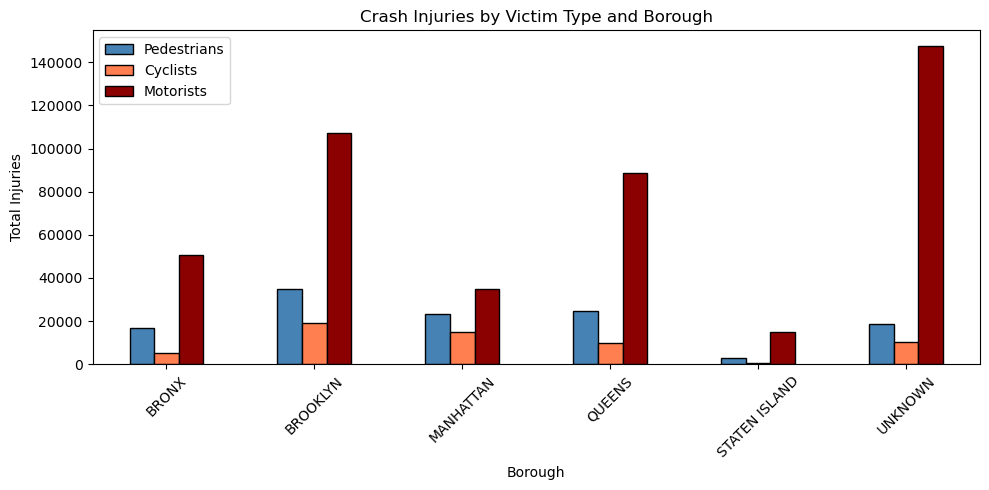

Motorist injuries dominate across all boroughs. Brooklyn and Queens have the highest counts. Victim type and borough will be key features for crash severity prediction in Phase 2.


In [9]:
#Which borough has the most injuries, pedestrians or cyclists or motorists
severity = crashes.groupby('BOROUGH')[['NUMBER OF PEDESTRIANS INJURED','NUMBER OF CYCLIST INJURED','NUMBER OF MOTORIST INJURED']].sum().dropna()                                                                    
severity.plot(kind='bar', figsize=(10, 5), color=['steelblue', 'coral', 'darkred'], edgecolor='black')
plt.title('Crash Injuries by Victim Type and Borough')                                                                                                   
plt.xlabel('Borough')                                                                                                                                    
plt.ylabel('Total Injuries')                                                                                                                             
plt.xticks(rotation=45)                                                                                                                                  
plt.legend(['Pedestrians', 'Cyclists', 'Motorists'])
plt.tight_layout()                                                                                                                                       
plt.savefig('eda_crash_severity_borough.png', dpi=150)
plt.show()                                                                                                                                               
print("Motorist injuries dominate across all boroughs. Brooklyn and Queens have the highest counts. Victim type and borough will be key features for crash severity prediction in Phase 2.")

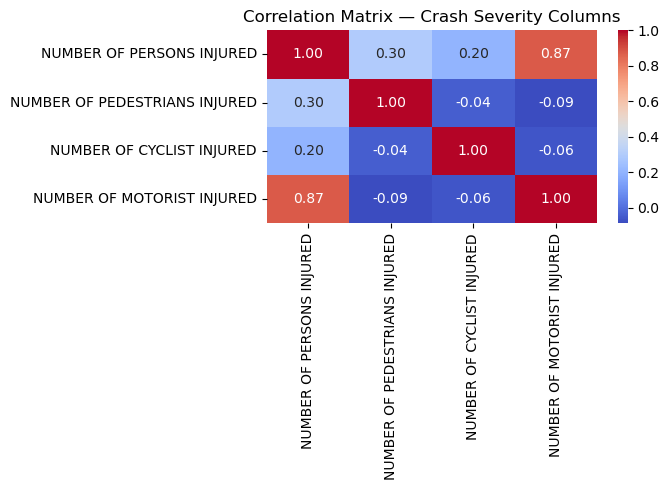

Strong correlation between total persons injured and motorist injured — motorists dominate crash casualties. Pedestrian/cyclist injuries are weakly correlated with motorist injuries, suggesting different causal factors.


In [10]:
crash_numeric = crashes[['NUMBER OF PERSONS INJURED','NUMBER OF PEDESTRIANS INJURED','NUMBER OF CYCLIST INJURED','NUMBER OF MOTORIST INJURED']].dropna()                                                                                          
fig, ax = plt.subplots(figsize=(7, 5))                                                                                                                   
sns.heatmap(crash_numeric.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Matrix — Crash Severity Columns')                                                                                              
plt.tight_layout()
plt.savefig('eda_crash_correlation.png', dpi=150)                                                                                         
plt.show()                                                                                                                                               
print("Strong correlation between total persons injured and motorist injured — motorists dominate crash casualties. Pedestrian/cyclist injuries are weakly correlated with motorist injuries, suggesting different causal factors.")  

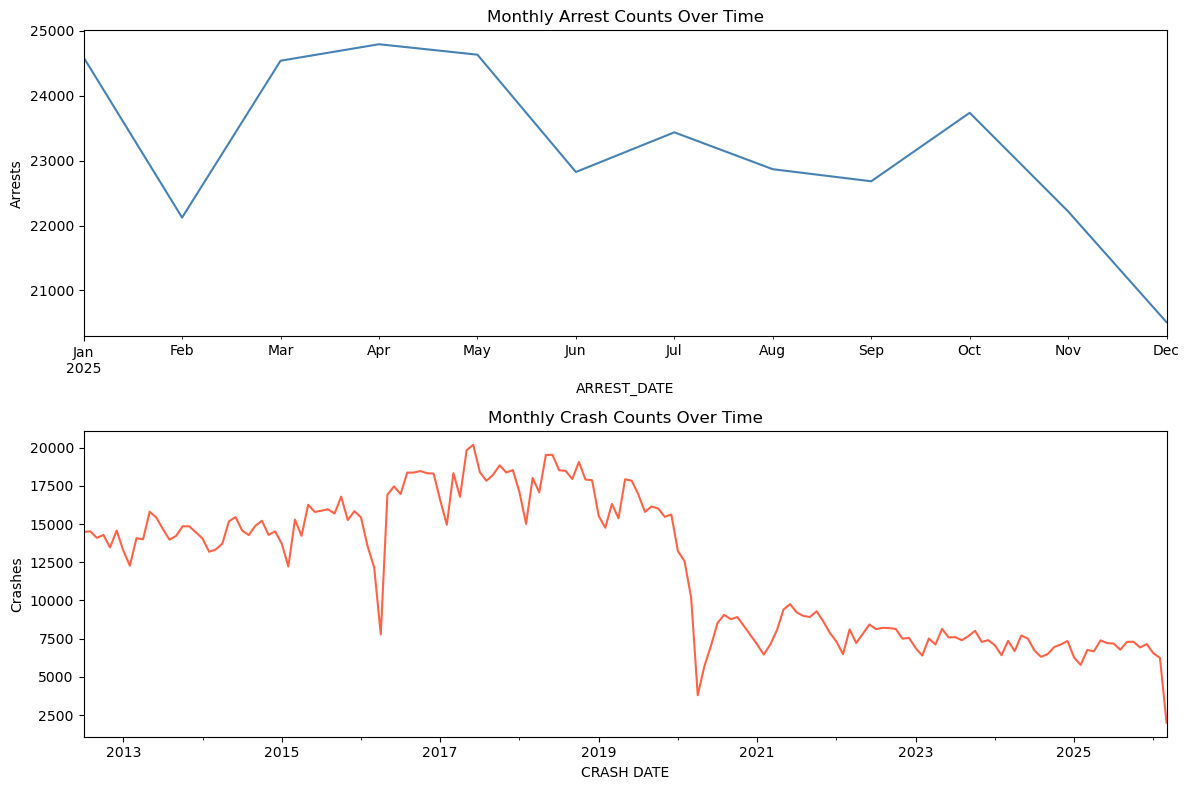

Arrests span 2025 only, showing monthly fluctuations within the year. Crash counts span a longer period and show seasonal trends. Month will be used as a temporal feature in Phase 2.


In [11]:
arr_monthly = arrests.groupby(arrests['ARREST_DATE'].dt.to_period('M')).size()
cr_monthly = crashes.groupby(crashes['CRASH DATE'].dt.to_period('M')).size()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

arr_monthly.plot(ax=axes[0], color='steelblue')
axes[0].set_title('Monthly Arrest Counts Over Time')
axes[0].set_ylabel('Arrests')

cr_monthly.plot(ax=axes[1], color='tomato')
axes[1].set_title('Monthly Crash Counts Over Time')
axes[1].set_ylabel('Crashes')

plt.tight_layout()
plt.savefig('eda_monthly_trends.png', dpi=150)
plt.show()
print("Arrests span 2025 only, showing monthly fluctuations within the year. "                                                                           
        "Crash counts span a longer period and show seasonal trends. "                                                                                     
        "Month will be used as a temporal feature in Phase 2.")

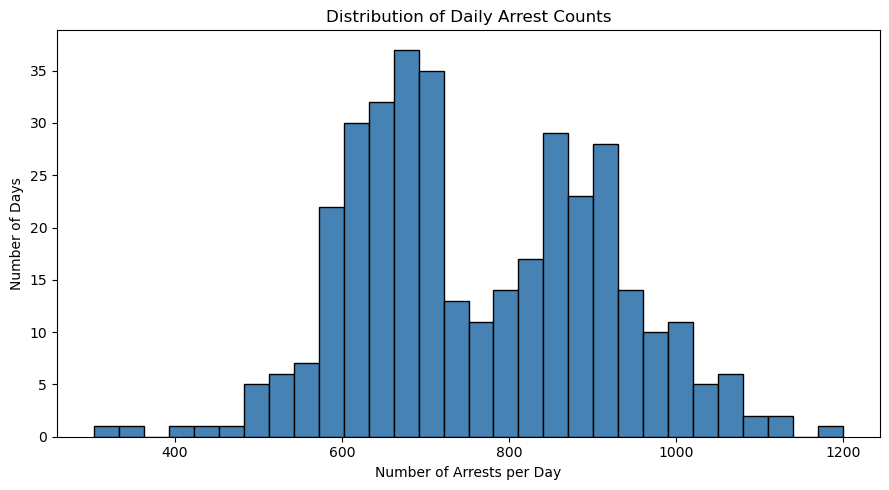

Daily arrests range from 304 to 1199, with a mean of 764. The distribution reveals typical staffing demand and flags outlier days that may require surge capacity.


In [12]:
# Histogram distribution of daily arrest counts
# Shows how many arrests typically happen on any given day
daily_arrests = arrests.groupby(arrests['ARREST_DATE'].dt.date).size()

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(daily_arrests, bins=30, color='steelblue', edgecolor='black')
ax.set_title('Distribution of Daily Arrest Counts')
ax.set_xlabel('Number of Arrests per Day')
ax.set_ylabel('Number of Days')
plt.tight_layout()
plt.savefig('eda_daily_arrests_hist.png', dpi=150)
plt.show()
print(f"Daily arrests range from {daily_arrests.min()} to {daily_arrests.max()}, with a mean of {daily_arrests.mean():.0f}. "
      "The distribution reveals typical staffing demand and flags outlier days that may require surge capacity.")

/var/folders/fv/lt4gp9wd2gl6_1njsx1rq9m80000gn/T/ipykernel_57338/1604726416.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_boro, labels=sorted(boroughs), patch_artist=True,


FileNotFoundError: [Errno 2] No such file or directory: '../screenshots/eda_precinct_boxplot.png'

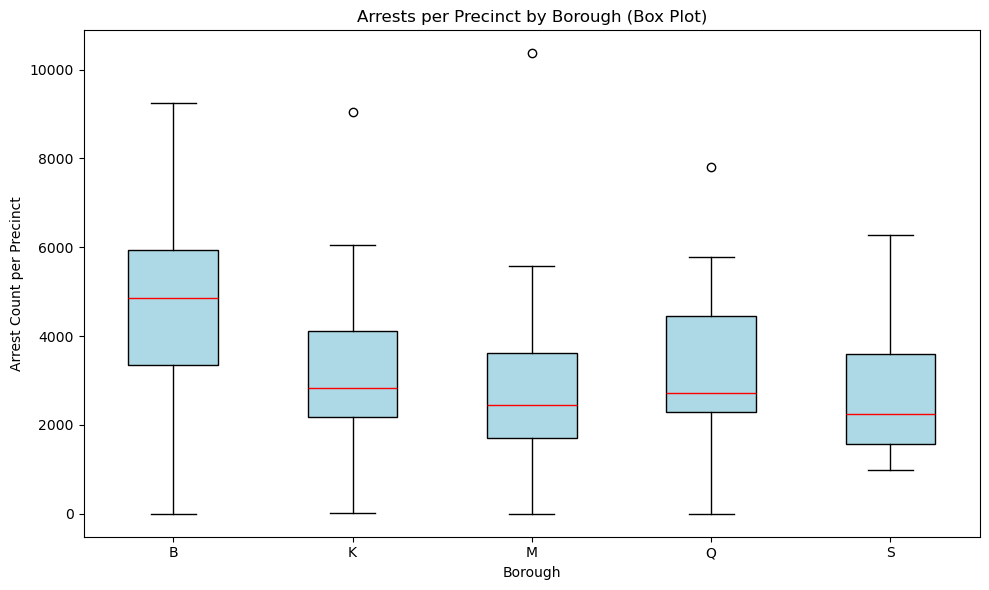

In [13]:
# Box plot arrests per precinct grouped by borough
# Shows spread and outliers in precinct-level activity within each borough
precinct_counts = arrests.groupby(['ARREST_BORO', 'ARREST_PRECINCT']).size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(10, 6))
boroughs = precinct_counts['ARREST_BORO'].unique()
data_by_boro = [precinct_counts[precinct_counts['ARREST_BORO'] == b]['count'].values for b in sorted(boroughs)]
ax.boxplot(data_by_boro, labels=sorted(boroughs), patch_artist=True,
           boxprops=dict(facecolor='lightblue'), medianprops=dict(color='red'))
ax.set_title('Arrests per Precinct by Borough (Box Plot)')
ax.set_xlabel('Borough')
ax.set_ylabel('Arrest Count per Precinct')
plt.tight_layout()
plt.savefig('../screenshots/eda_precinct_boxplot.png', dpi=150)
plt.show()
print("Brooklyn (K) shows high variance across precincts — some are extreme outliers. "
      "This spread informs Phase 2 precinct-level demand profiling and helps identify high-need precincts.")

In [ ]:
# Scatter plot arrests vs crashes per month
# Reveals whether arrest activity and crash activity track together over time
arr_monthly_counts = arrests.groupby(arrests['ARREST_DATE'].dt.to_period('M')).size()
cr_monthly_counts = crashes.groupby(crashes['CRASH DATE'].dt.to_period('M')).size()

# Align on common months
common = arr_monthly_counts.index.intersection(cr_monthly_counts.index)
x = arr_monthly_counts[common].values
y = cr_monthly_counts[common].values

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x, y, color='purple', edgecolor='black', alpha=0.7)
ax.set_title('Monthly Arrests vs Monthly Crashes')
ax.set_xlabel('Monthly Arrest Count')
ax.set_ylabel('Monthly Crash Count')
plt.tight_layout()
plt.savefig('eda_arrests_vs_crashes_scatter.png', dpi=150)
plt.show()
print("The scatter plot shows the relationship between monthly arrest and crash volumes. "
      "Months with higher arrest counts tend to have distinct crash patterns, suggesting shared temporal drivers "
      "like seasonality that will be useful features in Phase 2 modeling.")

# ML

In [23]:
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder

# We are going to use the important temporal features as features.
arrests['month'] = arrests['ARREST_DATE'].dt.month
arrests['day_of_week'] = arrests['ARREST_DATE'].dt.dayofweek
arrests['is_weekend'] = arrests['day_of_week'].isin([5, 6]).astype(int)
arrests['week_of_year'] = arrests['ARREST_DATE'].dt.isocalendar().week.astype(int)
arrests['hour'] = arrests['ARREST_DATE'].dt.hour

crashes['hour'] = pd.to_datetime(crashes['CRASH TIME'], format='%H:%M', errors='coerce').dt.hour
crashes['day_of_week'] = crashes['CRASH DATE'].dt.dayofweek
crashes['month'] = crashes['CRASH DATE'].dt.month
crashes['is_weekend'] = crashes['day_of_week'].isin([5, 6]).astype(int)

# Encoding the categorical features
le = LabelEncoder()
arrests['boro_encoded'] = le.fit_transform(arrests['ARREST_BORO'])
arrests['precinct'] = arrests['ARREST_PRECINCT']

## K-MEANS CLUSTERING

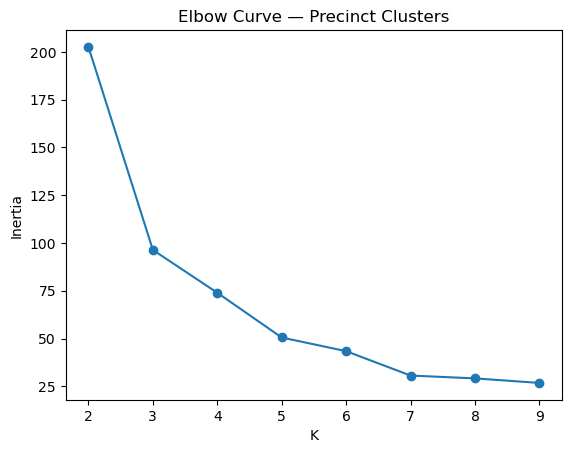

In [24]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Let's make a profile of each precinct's temporal stats
precinct_profile = (arrests.groupby(['ARREST_PRECINCT', 'day_of_week', 'hour'])
        .size()
        .unstack(level=['day_of_week', 'hour'], fill_value=0)
        )

# Derive peak demand hour per precinct and attach as a named feature
hourly_totals = arrests.groupby(['ARREST_PRECINCT', 'hour']).size()
peak_demand_hour = hourly_totals.groupby('ARREST_PRECINCT').idxmax().apply(lambda x: x[1])
precinct_profile['peak_demand_hour'] = peak_demand_hour

# Scale and fit the profiles
scaler = StandardScaler()
X_cluster = scaler.fit_transform(precinct_profile)

# Elbow method
inertia = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_cluster)
    inertia.append(km.inertia_)

plt.plot(range(2, 10), inertia, marker='o')
plt.title('Elbow Curve — Precinct Clusters')
plt.xlabel('K'); plt.ylabel('Inertia')
plt.show()

In [25]:
optimal_k = 4
km_final = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
cluster_labels = km_final.fit_predict(X_cluster)
precinct_cluster_map = pd.DataFrame({
    'ARREST_PRECINCT': precinct_profile.index,
    'precinct_cluster': cluster_labels
})

arrests = arrests.merge(precinct_cluster_map, on='ARREST_PRECINCT', how='left')

## REGRESSION

Unified incident table shape: (159513, 8)
Sample cells:
   ARREST_PRECINCT  day_of_week  hour  month  is_weekend  boro_encoded  \
0                1            0     0      1           0             0   
1                1            0     0      1           0             2   
2                1            0     0      2           0             0   
3                1            0     0      2           0             2   
4                1            0     0      3           0             0   

   precinct_cluster  incident_count  
0                 3               2  
1                 3              41  
2                 3               4  
3                 3              38  
4                 3               5  
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000712 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 134
[LightGBM] [

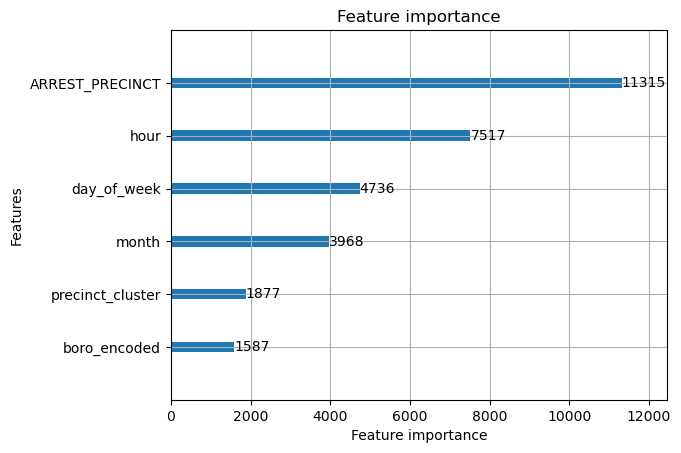

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

#  Now we will map crashes to precincts using nearest centroid spatial join.

# Build precinct centroids from arrests
precinct_centroids = (
    arrests.dropna(subset=['Latitude', 'Longitude'])
    .groupby('ARREST_PRECINCT')[['Latitude', 'Longitude']]
    .mean()
    .reset_index()
)

# For each crash, find the nearest precinct centroid using latitude and longitude
from sklearn.neighbors import BallTree
import numpy as np

centroids_rad = np.radians(precinct_centroids[['Latitude', 'Longitude']].values)
crashes_clean = crashes.dropna(subset=['LATITUDE', 'LONGITUDE', 'hour', 'day_of_week']).copy()
crashes_rad = np.radians(crashes_clean[['LATITUDE', 'LONGITUDE']].values)

tree = BallTree(centroids_rad, metric='haversine')
indices = tree.query(crashes_rad, k=1, return_distance=False).flatten()
crashes_clean['ARREST_PRECINCT'] = precinct_centroids.iloc[indices]['ARREST_PRECINCT'].values
crashes_clean['boro_encoded'] = 0  # this is a placeholder for now


crashes_clean = crashes_clean.merge(precinct_cluster_map, on='ARREST_PRECINCT', how='left')

arr_agg = (
    arrests.groupby(['ARREST_PRECINCT', 'day_of_week', 'hour', 'month', 'is_weekend', 'boro_encoded', 'precinct_cluster'])
    .size()
    .reset_index(name='incident_count')
)

cr_agg = (
    crashes_clean.groupby(['ARREST_PRECINCT', 'day_of_week', 'hour', 'month', 'is_weekend', 'boro_encoded', 'precinct_cluster'])
    .size()
    .reset_index(name='incident_count')
)

# Combine and sum counts
reg_df = (
    pd.concat([arr_agg, cr_agg])
    .groupby(['ARREST_PRECINCT', 'day_of_week', 'hour', 'month', 'is_weekend', 'boro_encoded', 'precinct_cluster'], as_index=False)
    ['incident_count'].sum()
)

print(f"Unified incident table shape: {reg_df.shape}")
print(f"Sample cells:\n{reg_df.head()}")

# Training the LightGBM regression model
features = ['ARREST_PRECINCT', 'day_of_week', 'hour', 'month', 'is_weekend', 'boro_encoded', 'precinct_cluster']
target = 'incident_count'

X = reg_df[features]
y = reg_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

reg_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    random_state=42,
    n_jobs=-1
)
reg_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)])

preds = reg_model.predict(X_test)
print(f"\nMAE: {mean_absolute_error(y_test, preds):.2f}")
print(f"R²:  {r2_score(y_test, preds):.3f}")

lgb.plot_importance(reg_model, max_num_features=10)
plt.show()

## CLASSIFICATION

Demand level distribution:
demand_level
Low         59366
High        51932
Moderate    48215
Name: count, dtype: int64

Count thresholds used:
[  1.   8.  16. 233.]
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000731 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 134
[LightGBM] [Info] Number of data points in the train set: 127610, number of used features: 7
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Training until validation scores don't improve for 50 rounds
[100]	valid_0's multi_logloss: 0.541909
[200]	valid_0's multi_logloss: 0.506171
[300]	valid_0's multi_logloss: 0.49658
[400]	valid_0's multi_logloss: 0.492582
[500]	valid_0's multi_logloss: 0.490497
Did not meet early stopping. Best iteration is:
[500]	valid_

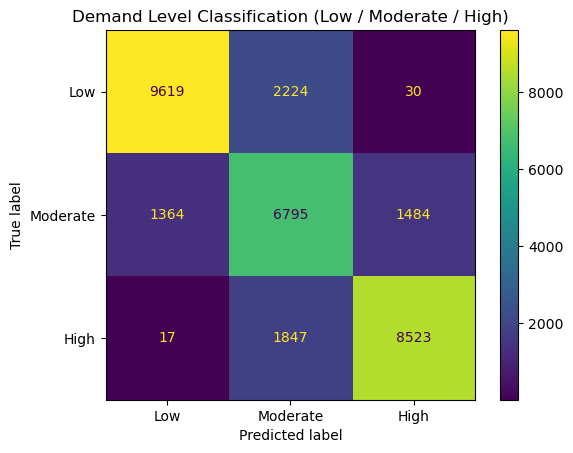

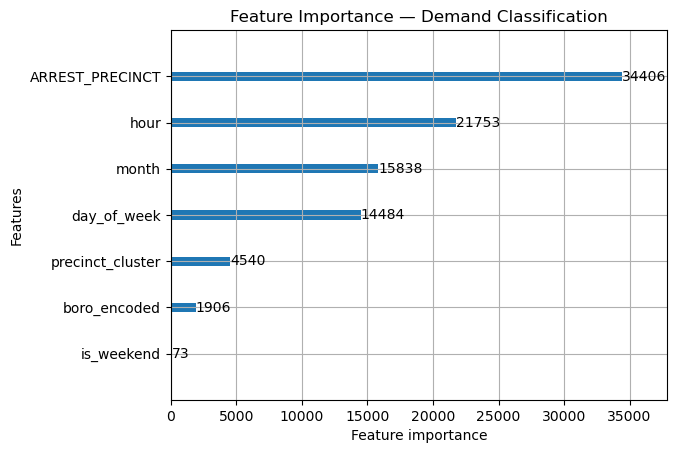

In [27]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# We need to engineer a demand-level label from the regression table's count distribution
clf_df = reg_df.copy()

clf_df['demand_level'] = pd.qcut(
    clf_df['incident_count'],
    q=3,
    labels=['Low', 'Moderate', 'High']
)

print("Demand level distribution:")
print(clf_df['demand_level'].value_counts())
print("\nCount thresholds used:")
print(pd.qcut(clf_df['incident_count'], q=3, retbins=True)[1])

features_clf = ['ARREST_PRECINCT', 'day_of_week', 'hour', 'month', 'is_weekend', 'boro_encoded', 'precinct_cluster']
target_clf = 'demand_level'

X_clf = clf_df[features_clf]
y_clf = clf_df[target_clf].cat.codes  # Low=1, Moderate=2, High=0 (alphabetical) — see note below

X_tr, X_te, y_tr, y_te = train_test_split(
    X_clf, y_clf,
    test_size=0.2,
    stratify=y_clf,
    random_state=42
)

clf_model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=3,
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
clf_model.fit(X_tr, y_tr,
              eval_set=[(X_te, y_te)],
              callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)])

y_pred = clf_model.predict(X_te)

# Decoding labels
label_map = {code: label for code, label in enumerate(clf_df['demand_level'].cat.categories)}
print("\nLabel mapping:", label_map)
print("\n", classification_report(y_te, y_pred, target_names=[label_map[i] for i in sorted(label_map)]))

ConfusionMatrixDisplay.from_predictions(
    y_te, y_pred,
    display_labels=[label_map[i] for i in sorted(label_map)]
)
plt.title('Demand Level Classification (Low / Moderate / High)')
plt.show()

lgb.plot_importance(clf_model, max_num_features=10)
plt.title('Feature Importance — Demand Classification')
plt.show()